In [1]:
from pathlib import Path

import pandas as pd


# Detecta a raiz do projeto mesmo que o notebook esteja dentro da pasta notebooks/
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

HORAS_PATH = PROJECT_ROOT / "data" / "processed" / "horas_trabalho.csv"
PRECOS_PATH = PROJECT_ROOT / "data" / "processed" / "preco_cesta.csv"

horas = pd.read_csv(HORAS_PATH)
precos = pd.read_csv(PRECOS_PATH)

print("Raiz do projeto:", PROJECT_ROOT)
print("Arquivo horas:", HORAS_PATH)
print("Arquivo preços:", PRECOS_PATH)

print("\nHoras de trabalho:")
display(horas.head())

print("\nPreço da cesta:")
display(precos.head())

print("\nDimensões:")
print("horas:", horas.shape)
print("preços:", precos.shape)

Raiz do projeto: C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil
Arquivo horas: C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\data\processed\horas_trabalho.csv
Arquivo preços: C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\data\processed\preco_cesta.csv

Horas de trabalho:


,mes_ano,valor_original,cidade,metrica,valor_minutos
0,01-1989,154h45m,São Paulo,horas_trabalho,9285.0
1,02-1989,176h22m,São Paulo,horas_trabalho,10582.0
2,03-1989,194h21m,São Paulo,horas_trabalho,11661.0
3,04-1989,207h03m,São Paulo,horas_trabalho,12423.0
4,05-1989,197h01m,São Paulo,horas_trabalho,11821.0



Preço da cesta:


,mes_ano,valor_original,cidade,metrica,valor_reais
0,01-1989,44.95,São Paulo,preco_cesta,44.95
1,02-1989,51.23,São Paulo,preco_cesta,51.23
2,03-1989,56.45,São Paulo,preco_cesta,56.45
3,04-1989,60.14,São Paulo,preco_cesta,60.14
4,05-1989,72.90,São Paulo,preco_cesta,72.90



Dimensões:
horas: (1728, 5)
preços: (1728, 5)


In [2]:
# Conversão da coluna mes_ano para data
horas["data"] = pd.to_datetime(horas["mes_ano"], format="%m-%Y")
precos["data"] = pd.to_datetime(precos["mes_ano"], format="%m-%Y")

# Criação de colunas auxiliares
horas["ano"] = horas["data"].dt.year
horas["mes"] = horas["data"].dt.month
horas["horas_decimal"] = horas["valor_minutos"] / 60

precos["ano"] = precos["data"].dt.year
precos["mes"] = precos["data"].dt.month

print("Período analisado:")
print("Horas:", horas["data"].min().strftime("%m-%Y"), "até", horas["data"].max().strftime("%m-%Y"))
print("Preços:", precos["data"].min().strftime("%m-%Y"), "até", precos["data"].max().strftime("%m-%Y"))

print("\nCidades em horas:")
print(horas["cidade"].unique())

print("\nCidades em preços:")
print(precos["cidade"].unique())

print("\nValores ausentes em horas:")
display(horas[horas["valor_minutos"].isna()])

print("\nValores ausentes em preços:")
display(precos[precos["valor_reais"].isna()])

Período analisado:
Horas: 01-1989 até 12-2024
Preços: 01-1989 até 12-2024

Cidades em horas:
<StringArray>
['São Paulo', 'Belo Horizonte', 'Rio de Janeiro', 'Vitória']
Length: 4, dtype: str

Cidades em preços:
<StringArray>
['São Paulo', 'Belo Horizonte', 'Rio de Janeiro', 'Vitória']
Length: 4, dtype: str

Valores ausentes em horas:


,mes_ano,valor_original,cidade,metrica,valor_minutos,data,ano,mes,horas_decimal
820,05-2021,NaN,Belo Horizonte,horas_trabalho,NaN,2021-05-01,2021,5,NaN



Valores ausentes em preços:


,mes_ano,valor_original,cidade,metrica,valor_reais,data,ano,mes
820,05-2021,NaN,Belo Horizonte,preco_cesta,NaN,2021-05-01,2021,5


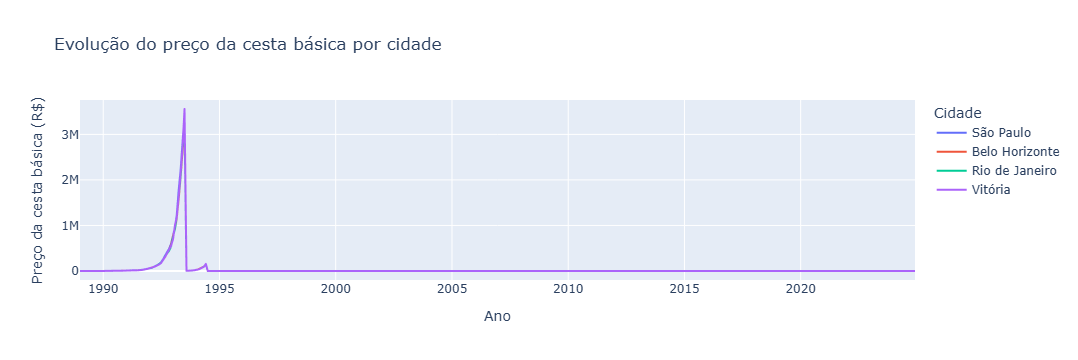

In [3]:
import plotly.express as px

fig_preco = px.line(
    precos,
    x="data",
    y="valor_reais",
    color="cidade",
    title="Evolução do preço da cesta básica por cidade",
    labels={
        "data": "Ano",
        "valor_reais": "Preço da cesta básica (R$)",
        "cidade": "Cidade"
    }
)

fig_preco.update_layout(
    xaxis_title="Ano",
    yaxis_title="Preço da cesta básica (R$)",
    legend_title="Cidade",
    hovermode="x unified"
)

fig_preco.show()

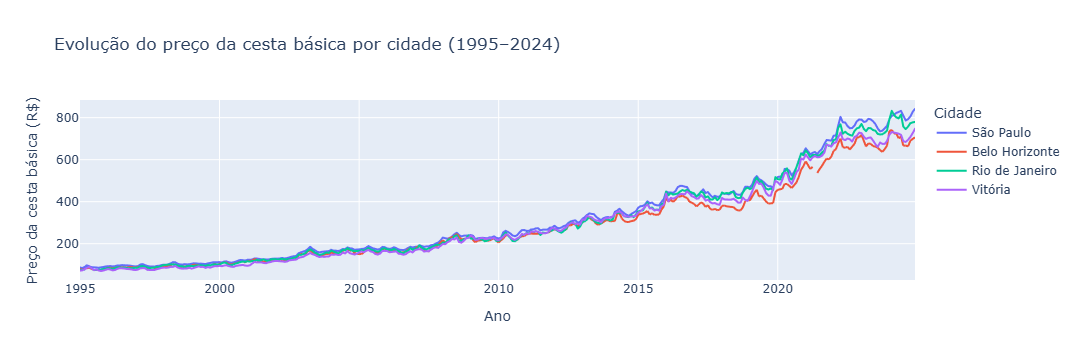

In [4]:
precos_pos_1995 = precos[precos["ano"] >= 1995].copy()

fig_preco_pos_1995 = px.line(
    precos_pos_1995,
    x="data",
    y="valor_reais",
    color="cidade",
    title="Evolução do preço da cesta básica por cidade (1995–2024)",
    labels={
        "data": "Ano",
        "valor_reais": "Preço da cesta básica (R$)",
        "cidade": "Cidade"
    }
)

fig_preco_pos_1995.update_layout(
    xaxis_title="Ano",
    yaxis_title="Preço da cesta básica (R$)",
    legend_title="Cidade",
    hovermode="x unified"
)

fig_preco_pos_1995.show()

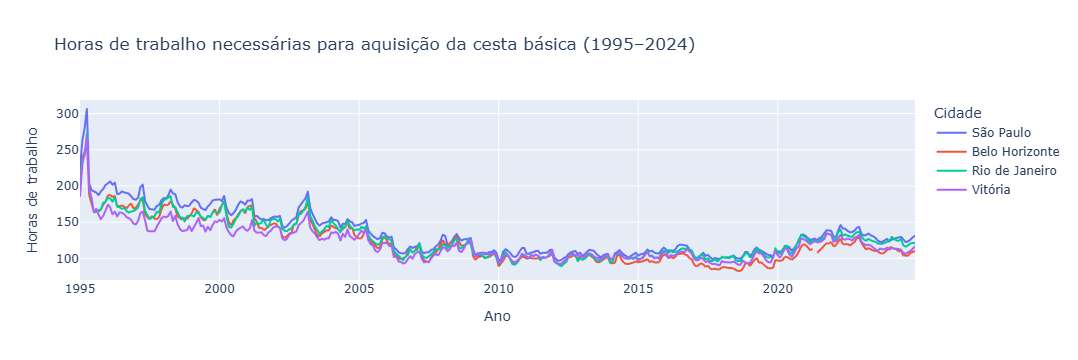

In [5]:
horas_pos_1995 = horas[horas["ano"] >= 1995].copy()

fig_horas_pos_1995 = px.line(
    horas_pos_1995,
    x="data",
    y="horas_decimal",
    color="cidade",
    title="Horas de trabalho necessárias para aquisição da cesta básica (1995–2024)",
    labels={
        "data": "Ano",
        "horas_decimal": "Horas de trabalho",
        "cidade": "Cidade"
    }
)

fig_horas_pos_1995.update_layout(
    xaxis_title="Ano",
    yaxis_title="Horas de trabalho",
    legend_title="Cidade",
    hovermode="x unified"
)

fig_horas_pos_1995.show()

In [6]:
CHARTS_PATH = PROJECT_ROOT / "outputs" / "charts"
CHARTS_PATH.mkdir(parents=True, exist_ok=True)

fig_preco_pos_1995.write_html(CHARTS_PATH / "preco_cesta_1995_2024.html")
fig_horas_pos_1995.write_html(CHARTS_PATH / "horas_trabalho_1995_2024.html")

print("Gráficos exportados para:")
print(CHARTS_PATH / "preco_cesta_1995_2024.html")
print(CHARTS_PATH / "horas_trabalho_1995_2024.html")

Gráficos exportados para:
C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\outputs\charts\preco_cesta_1995_2024.html
C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\outputs\charts\horas_trabalho_1995_2024.html


In [7]:
CHARTS_PATH = PROJECT_ROOT / "outputs" / "charts"
CHARTS_PATH.mkdir(parents=True, exist_ok=True)

fig_preco_pos_1995.write_html(CHARTS_PATH / "preco_cesta_1995_2024.html")
fig_horas_pos_1995.write_html(CHARTS_PATH / "horas_trabalho_1995_2024.html")

print("Gráficos exportados para:")
print(CHARTS_PATH / "preco_cesta_1995_2024.html")
print(CHARTS_PATH / "horas_trabalho_1995_2024.html")

Gráficos exportados para:
C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\outputs\charts\preco_cesta_1995_2024.html
C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\outputs\charts\horas_trabalho_1995_2024.html
